# Replication Plan Comparison: Spectral Distance Analysis

Compares two replication strategies against the source tenant's pattern graph using **spectral distance** — a measure of structural similarity between graphs.

## Plans Under Comparison

| Plan | Strategy | Selection Unit | Graph Representation |
|------|----------|----------------|----------------------|
| **A: Architecture Replication** | Pattern-instance selection with spectral guidance | Architectural pattern instances (coherent groups) | Type-level pattern graph built from selected instances |
| **B: Scale-Down Replication** | Graph sampling algorithms on instance graph | Individual resource nodes | Type-level graph projected from sampled instances |

## Spectral Distance
Uses the normalized Laplacian eigenvalue spectrum to compare graph structure:
- **0.0** = structurally identical
- **1.0** = maximally different

Lower spectral distance → the replication plan preserves more of the source tenant's architectural topology.

## 1. Setup

In [1]:
import asyncio
import os
import sys
from collections import defaultdict
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from neo4j import GraphDatabase

sys.path.insert(0, str(Path.cwd().parent))

from src.architectural_pattern_analyzer import ArchitecturalPatternAnalyzer
from src.architecture_based_replicator import ArchitecturePatternReplicator
from src.config_manager import Neo4jConfig
from src.replicator.modules.graph_structure_analyzer import GraphStructureAnalyzer
from src.services.scale_down.orchestrator import ScaleDownOrchestrator
from src.utils.session_manager import Neo4jSessionManager
from dotenv import find_dotenv, load_dotenv

# Enable nested event loops for Jupyter async support
try:
    import nest_asyncio
    nest_asyncio.apply()
    print('✅ nest_asyncio applied')
except ImportError:
    print('⚠️  nest_asyncio not found — install with: pip install nest_asyncio')

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline
print('✅ Setup complete')

✅ nest_asyncio applied
✅ Setup complete


## 2. Configuration

In [2]:
load_dotenv(find_dotenv())  # finds .env walking up from cwd

NEO4J_URI      = os.getenv('NEO4J_URI', 'bolt://localhost:7687')
NEO4J_USER     = os.getenv('NEO4J_USER', 'neo4j')
NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD')

# Sweep: generate replication plans at these architecture instance counts
INSTANCE_COUNTS = list(range(10, 251, 20))  # [25, 50, 75, ..., 250]

# Scale-down algorithms to compare against Plan A
SCALE_DOWN_ALGORITHMS = ['forest_fire', 'mhrw', 'random_walk']

print(f'Neo4j URI:              {NEO4J_URI}')
print(f'Instance count sweep:   {INSTANCE_COUNTS}')
print(f'Scale-down algorithms:  {SCALE_DOWN_ALGORITHMS}')

Neo4j URI:              bolt://localhost:7687
Instance count sweep:   [10, 30, 50, 70, 90, 110, 130, 150, 170, 190, 210, 230, 250]
Scale-down algorithms:  ['forest_fire', 'mhrw', 'random_walk']


---
## 3. Source Tenant — Pattern Graph
Build the shared source pattern graph used as the reference for all spectral distance calculations.

In [3]:
print('🔍 Building source pattern graph and identifying orphaned nodes...')

analyzer = ArchitecturalPatternAnalyzer(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD)
analyzer.connect()

all_relationships  = analyzer.fetch_all_relationships()
aggregated_rels    = analyzer.aggregate_relationships(all_relationships)
source_pattern_graph, source_type_counts, edge_counts = analyzer.build_networkx_graph(aggregated_rels)
detected_patterns  = analyzer.detect_patterns(source_pattern_graph, source_type_counts)

# Identify orphaned nodes (types not matched by any detected pattern)
orphaned_nodes     = analyzer.identify_orphaned_nodes(source_pattern_graph, detected_patterns)

# Suggest new patterns to absorb orphans
suggested_patterns = analyzer.suggest_new_patterns(orphaned_nodes, source_pattern_graph)

analyzer.close()

source_nodes = set(source_pattern_graph.nodes())

# ── Build improved pattern matches (original + orphan-absorbing suggestions) ──
# Mirrors architecture_pattern_analysis.ipynb cell-20 logic
improved_pattern_matches = {}
for name, match in detected_patterns.items():
    improved_pattern_matches[name] = {
        'matched_resources': set(match['matched_resources']),
        'completeness':      match['completeness'],
        'source':            'original',
    }

high_confidence = [p for p in suggested_patterns if p.get('confidence', 0) > 0.5]

for pattern in high_confidence:
    if pattern.get('action') == 'UPDATE_EXISTING':
        target = pattern['target_pattern']
        if target in improved_pattern_matches:
            improved_pattern_matches[target]['matched_resources'].add(pattern['resource_to_add'])
    else:
        pname    = pattern['suggested_name']
        required = set(pattern.get('required_resources', []))
        optional = set(pattern.get('optional_resources', []))
        improved_pattern_matches[pname] = {
            'matched_resources': required | optional,
            'completeness':      pattern.get('confidence', 0.5) * 100,
            'source':            'suggested',
        }

# Compute coverage before / after orphan absorption
all_improved_matched  = set()
for m in improved_pattern_matches.values():
    all_improved_matched.update(m['matched_resources'])
improved_orphaned_set = source_nodes - all_improved_matched

n_total   = source_pattern_graph.number_of_nodes()
n_matched = n_total - len(orphaned_nodes)

print(f'\n📊 Source Pattern Graph:')
print(f'   Resource types (nodes):      {n_total}')
print(f'   Relationship patterns (edges): {source_pattern_graph.number_of_edges()}')
print(f'   Total relationships sampled: {len(all_relationships):,}')
print(f'\n📐 Pattern Coverage:')
print(f'   Detected patterns:           {len(detected_patterns)}')
print(f'   Types in patterns:           {n_matched}/{n_total} ({n_matched/n_total:.1%})')
print(f'   Orphaned types:              {len(orphaned_nodes)}')
print(f'   High-confidence suggestions: {len(high_confidence)}')
n_improved = n_total - len(improved_orphaned_set)
print(f'   Improved coverage:           {n_improved}/{n_total} ({n_improved/n_total:.1%})')
print(f'\n📐 Detected Patterns:')
for name, info in detected_patterns.items():
    print(f'   {name:35s}  completeness: {info["completeness"]*100:.0f}%  '
          f'types: {len(info["matched_resources"])}')

🔍 Building source pattern graph and identifying orphaned nodes...

📊 Source Pattern Graph:
   Resource types (nodes):      94
   Relationship patterns (edges): 306
   Total relationships sampled: 16,856

📐 Pattern Coverage:
   Detected patterns:           10
   Types in patterns:           24/94 (25.5%)
   Orphaned types:              70
   High-confidence suggestions: 5
   Improved coverage:           94/94 (100.0%)

📐 Detected Patterns:
   Web Application                      completeness: 10000%  types: 4
   Virtual Machine Workload             completeness: 10000%  types: 5
   Container Platform                   completeness: 7500%  types: 3
   Data Platform                        completeness: 10000%  types: 4
   Serverless Application               completeness: 10000%  types: 4
   Data Analytics                       completeness: 10000%  types: 4
   Secure Workload                      completeness: 10000%  types: 4
   Managed Identity Pattern             completeness: 10000% 

In [4]:
# ── Orphaned node detail + suggested pattern breakdown ──
print(f'🔍 Top 15 Orphaned Resource Types (by connection count):')
print(f'{"#":>3}  {"Resource Type":<40}  {"Connections":>11}  {"Degree":>6}  Connects To')
print('-' * 90)
for i, node in enumerate(orphaned_nodes[:15], 1):
    connects = ', '.join(node['connected_to'][:3])
    if len(node['connected_to']) > 3:
        connects += f' (+{len(node["connected_to"])-3} more)'
    print(f'{i:>3}. {node["resource_type"]:<40}  {node["connection_count"]:>11,}  '
          f'{node["total_degree"]:>6}  {connects}')

print(f'\n💡 Pattern Suggestions ({len(suggested_patterns)} total, '
      f'{len(high_confidence)} high-confidence):')
for p in suggested_patterns[:5]:
    if p.get('action') == 'UPDATE_EXISTING':
        print(f'   [UPDATE] {p["target_pattern"]} ← add {p["resource_to_add"]}  '
              f'(confidence: {p.get("confidence",0):.2f}, {p["connection_count"]} connections)')
    else:
        req = p.get('required_resources', [])
        opt = p.get('optional_resources', [])
        print(f'   [NEW]    {p["suggested_name"]}  (confidence: {p.get("confidence",0):.2f})')
        print(f'            required: {req}')
        print(f'            optional ({len(opt)} types): {opt[:5]}{"..." if len(opt)>5 else ""}')

print(f'\n📈 Coverage summary:')
print(f'   Before orphan absorption:  {n_matched}/{n_total} ({n_matched/n_total:.1%})')
print(f'   After orphan absorption:   {n_improved}/{n_total} ({n_improved/n_total:.1%})')
print(f'   Patterns in improved set:  {len(improved_pattern_matches)} '
      f'({len(detected_patterns)} original + '
      f'{len(improved_pattern_matches)-len(detected_patterns)} suggested)')

🔍 Top 15 Orphaned Resource Types (by connection count):
  #  Resource Type                             Connections  Degree  Connects To
------------------------------------------------------------------------------------------
  1. Subscription                                    4,189      85  actiongroups, scheduledqueryrules, snapshots (+82 more)
  2. ResourceGroup                                   3,721      85  actiongroups, scheduledqueryrules, snapshots (+82 more)
  3. roleAssignments                                 3,443       5  ResourceGroup, Subscription, servicePrincipals (+2 more)
  4. Region                                          2,597      83  actiongroups, scheduledqueryrules, snapshots (+80 more)
  5. Tag                                             2,107      42  containerGroups, solutions, serverFarms (+39 more)
  6. servicePrincipals                               1,395       2  RoleDefinition, roleAssignments
  7. RoleDefinition                                  1,09

---
## 4. Architecture-Based Replication — Source Analysis
Analyze the source tenant once. The full sweep (Section 6) iterates over multiple instance counts.

In [5]:
print('🏗️  Analyzing source tenant for Plan A...')

replicator = ArchitecturePatternReplicator(
    neo4j_uri=NEO4J_URI,
    neo4j_user=NEO4J_USER,
    neo4j_password=NEO4J_PASSWORD
)

analysis = replicator.analyze_source_tenant(
    use_configuration_coherence=True,
    coherence_threshold=0.5,
    include_colocated_orphaned_resources=True,
)

print(f'\n📊 Plan A Source Analysis:')
print(f'   Resource types:          {analysis["resource_types"]}')
print(f'   Pattern graph edges:     {analysis["pattern_graph_edges"]}')
print(f'   Detected patterns:       {analysis["detected_patterns"]}')
print(f'   Total pattern instances: {analysis.get("total_pattern_resources", 0)}')

🏗️  Analyzing source tenant for Plan A...

📊 Plan A Source Analysis:
   Resource types:          94
   Pattern graph edges:     306
   Detected patterns:       10
   Total pattern instances: 940


In [6]:
print('📊 Pattern resources loaded — sweep summary:')
print()
total_available = 0
for name, instances in replicator.pattern_resources.items():
    n = len(instances)
    total_available += n
    if n > 0:
        print(f'   {name:35s}: {n:4d} instances')
print(f'\n   Total pattern instances: {total_available}')
print(f'\n📋 Sweep plan: {len(INSTANCE_COUNTS)} iterations × {1 + len(SCALE_DOWN_ALGORITHMS)} approaches')
print(f'   Instance counts:        {INSTANCE_COUNTS}')
print(f'   Approaches per count:   Plan A (architecture) + {SCALE_DOWN_ALGORITHMS}')
print(f'\n✅ Continue to Plan B infrastructure setup (cells below), then run the sweep')

📊 Pattern resources loaded — sweep summary:

   Web Application                    :   64 instances
   Virtual Machine Workload           :   65 instances
   Container Platform                 :   72 instances
   Data Platform                      :   61 instances
   Serverless Application             :  109 instances
   Data Analytics                     :   87 instances
   Secure Workload                    :   70 instances
   Managed Identity Pattern           :   90 instances
   Monitoring & Observability         :   54 instances
   Network Security                   :   50 instances
   orphaned_resources                 :  218 instances

   Total pattern instances: 940

📋 Sweep plan: 13 iterations × 4 approaches
   Instance counts:        [10, 30, 50, 70, 90, 110, 130, 150, 170, 190, 210, 230, 250]
   Approaches per count:   Plan A (architecture) + ['forest_fire', 'mhrw', 'random_walk']

✅ Continue to Plan B infrastructure setup (cells below), then run the sweep


In [7]:
# Single-shot plan generation replaced by the multi-count sweep in Section 6.
# Run Plan B setup cells below, then execute the sweep.
print('ℹ️  Single-shot plan generation skipped — see Section 6 sweep for full comparison.')
print('   Continue to Plan B setup cells (orchestrator + instance graph extraction).')

ℹ️  Single-shot plan generation skipped — see Section 6 sweep for full comparison.
   Continue to Plan B setup cells (orchestrator + instance graph extraction).


---
## 5. Plan B — Scale-Down Replication
Uses `ScaleDownOrchestrator` to sample individual resource instances with different graph sampling algorithms.
Each sampled instance-level graph is then projected to a type-level pattern graph for spectral comparison.

In [8]:
def instance_graph_to_type_graph(sampled_graph: nx.DiGraph, node_properties: dict) -> nx.MultiDiGraph:
    """
    Project an instance-level sampled graph to a type-level pattern graph.

    Mirrors ArchitecturalPatternAnalyzer.aggregate_relationships() logic:
    - Nodes  = unique resource types  (last component of Azure type string)
    - Edges  = type-to-type relationships present in the sample
    """
    def extract_type(node_id: str) -> str:
        props = node_properties.get(node_id, {})
        azure_type = props.get('type', '')
        if azure_type:
            parts = azure_type.split('/')
            return parts[-1] if len(parts) >= 2 else parts[0]
        # Fallback: use a short form of the node id
        return 'Unknown'

    type_graph = nx.MultiDiGraph()

    for node_id in sampled_graph.nodes():
        type_name = extract_type(node_id)
        if not type_graph.has_node(type_name):
            type_graph.add_node(type_name)

    for u, v, data in sampled_graph.edges(data=True):
        u_type = extract_type(u)
        v_type = extract_type(v)
        if u_type != 'Unknown' and v_type != 'Unknown':
            type_graph.add_edge(u_type, v_type, **data)

    return type_graph

print('✅ Helper function defined: instance_graph_to_type_graph')

✅ Helper function defined: instance_graph_to_type_graph


In [ ]:
# Get tenant_id from Neo4j
with GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD)) as driver:
    with driver.session() as session:
        result = session.run('MATCH (t:Tenant) RETURN t.id AS tenant_id LIMIT 1')
        record = result.single()
        TENANT_ID = record['tenant_id'] if record else None

if not TENANT_ID:
    raise RuntimeError('No Tenant node found in Neo4j — ensure a scan has been completed')

print(f'✅ Tenant ID: {TENANT_ID}')

# Build session manager, connect explicitly, then build orchestrator
neo4j_config    = Neo4jConfig(uri=NEO4J_URI, user=NEO4J_USER, password=NEO4J_PASSWORD)
session_manager = Neo4jSessionManager(neo4j_config)
session_manager.connect()  # required before any session() calls

orchestrator = ScaleDownOrchestrator(session_manager)

print('✅ Neo4jSessionManager connected')
print('✅ ScaleDownOrchestrator ready')

In [10]:
print('📥 Extracting full instance-level resource graph from Neo4j...')
print('   (Queries :Resource nodes — excludes infrastructure nodes like Subscription, Region, etc.)')

G_full, node_properties = await orchestrator.neo4j_to_networkx(TENANT_ID)

TOTAL_SOURCE_RESOURCES = G_full.number_of_nodes()

print(f'\n✅ Full resource graph:')
print(f'   Nodes (resource instances): {TOTAL_SOURCE_RESOURCES:,}')
print(f'   Edges (relationships):      {G_full.number_of_edges():,}')
print(f'\n📌 Plan B will sample a node count matching each Plan A resource output')
print(f'   Max sample size: {TOTAL_SOURCE_RESOURCES:,} nodes')

📥 Extracting full instance-level resource graph from Neo4j...
   (Queries :Resource nodes — excludes infrastructure nodes like Subscription, Region, etc.)

✅ Full resource graph:
   Nodes (resource instances): 6,869
   Edges (relationships):      1,473

📌 Plan B will sample a node count matching each Plan A resource output
   Max sample size: 6,869 nodes


In [11]:
import time

print(f'🚀 Starting sweep over {len(INSTANCE_COUNTS)} instance counts...')
print(f'   Each iteration: Plan A + {len(SCALE_DOWN_ALGORITHMS)} Plan B algorithms\n')

sweep_results = {}  # count -> {plan_a_instances, plan_a_resources, plan_a, algo1, ...}

for count in INSTANCE_COUNTS:
    print(f'{"─"*62}')
    print(f'🔄  instance_count = {count}')

    # ── Plan A ──────────────────────────────────────────────────
    t0 = time.time()
    selected, _, _ = replicator.generate_replication_plan(
        target_instance_count=count,
        use_architecture_distribution=True,
        use_configuration_coherence=True,
        use_spectral_guidance=True,
        spectral_weight=0.4,
        sampling_strategy='coverage',
    )
    plan_a_resources = sum(len(inst) for _, inst in selected)
    target_graph_a   = replicator.target_builder.build_from_instances(selected)
    dist_a           = GraphStructureAnalyzer.compute_spectral_distance(source_pattern_graph, target_graph_a)
    t_a = time.time() - t0
    print(f'  Plan A:  {len(selected):3d} instances  {plan_a_resources:5d} resources  '
          f'spectral={dist_a:.4f}  ({t_a:.1f}s)')

    row = {
        'plan_a_instances': len(selected),
        'plan_a_resources': plan_a_resources,
        'plan_a': dist_a,
    }

    # ── Plan B: sample same resource count ──────────────────────
    target_node_count = min(plan_a_resources, G_full.number_of_nodes())
    for algo in SCALE_DOWN_ALGORITHMS:
        t0            = time.time()
        sampler       = orchestrator.samplers[algo]
        sampled_ids   = await sampler.sample(G_full, target_node_count)
        sampled_graph = G_full.subgraph(sampled_ids).copy()
        type_graph_b  = instance_graph_to_type_graph(sampled_graph, node_properties)
        dist_b        = GraphStructureAnalyzer.compute_spectral_distance(source_pattern_graph, type_graph_b)
        t_b = time.time() - t0
        row[algo] = dist_b
        print(f'  Plan B ({algo:12s}):  {len(sampled_ids):5,} nodes  '
              f'spectral={dist_b:.4f}  ({t_b:.1f}s)')

    sweep_results[count] = row

print(f'\n{"─"*62}')
print(f'✅ Sweep complete — {len(sweep_results)} data points collected')

🚀 Starting sweep over 13 instance counts...
   Each iteration: Plan A + 3 Plan B algorithms

──────────────────────────────────────────────────────────────
🔄  instance_count = 10
  Plan A:   13 instances    242 resources  spectral=0.0982  (1.5s)
  Plan B (forest_fire ):    242 nodes  spectral=0.1774  (0.0s)
  Plan B (mhrw        ):    242 nodes  spectral=0.0823  (0.1s)
  Plan B (random_walk ):    242 nodes  spectral=0.0663  (0.0s)
──────────────────────────────────────────────────────────────
🔄  instance_count = 30
  Plan A:   29 instances    618 resources  spectral=0.0484  (1.4s)
  Plan B (forest_fire ):    618 nodes  spectral=0.1677  (0.0s)
  Plan B (mhrw        ):    618 nodes  spectral=0.1031  (0.2s)
  Plan B (random_walk ):    618 nodes  spectral=0.0918  (0.1s)
──────────────────────────────────────────────────────────────
🔄  instance_count = 50
  Plan A:   50 instances    838 resources  spectral=0.0416  (1.8s)
  Plan B (forest_fire ):    838 nodes  spectral=0.1552  (0.0s)
  Plan 

---
## 6. Sweep: Plan A vs Plan B Across Instance Counts [25 → 250]
For each architecture instance count, generate a Plan A replication plan, record its resource count,
then run each Plan B scale-down algorithm at the same resource count.
Results are collected into `sweep_results` and plotted below.

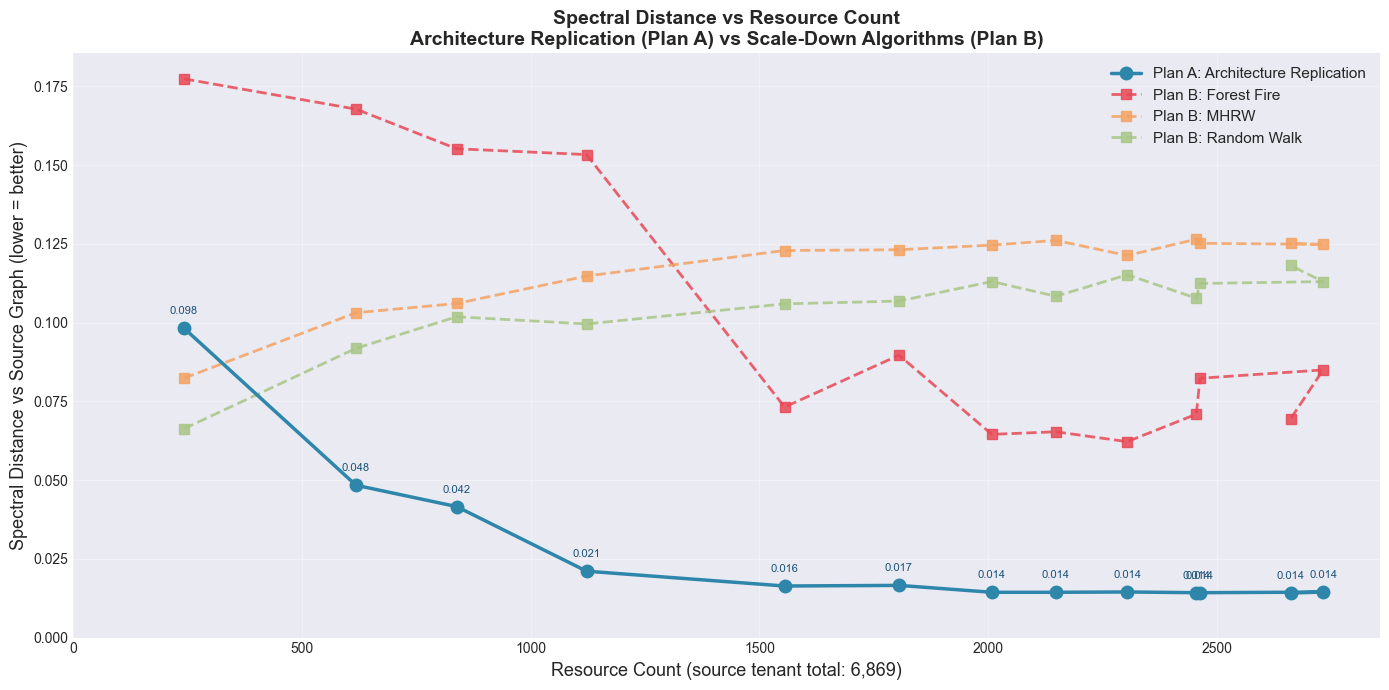


📊 Source tenant total resources: 6,869
     Sweep covers 242 – 2,732 resources (3.5% – 39.8% of source)

Inst Cnt  Resources  % of src         Plan A  forest_fire    mhrw           random_walk  
─────────────────────────────────────────────────────────────────────────────────────────
      10        242      3.5%         0.0982         0.1774         0.0823         0.0663
      30        618      9.0%         0.0484         0.1677         0.1031         0.0918
      50        838     12.2%         0.0416         0.1552         0.1060         0.1018
      70       1122     16.3%         0.0211         0.1533         0.1148         0.0995
      90       1555     22.6%         0.0164         0.0732         0.1229         0.1059
     110       1805     26.3%         0.0166         0.0896         0.1231         0.1068
     130       2008     29.2%         0.0144         0.0645         0.1246         0.1130
     150       2148     31.3%         0.0144         0.0653         0.1261         0

In [12]:
# ── Comparison plot: spectral distance vs resource count ───────────────────────
counts    = sorted(sweep_results.keys())
resources = [sweep_results[c]['plan_a_resources'] for c in counts]
dist_a    = [sweep_results[c]['plan_a'] for c in counts]

algo_colors = {
    'forest_fire':  '#E84855',
    'mhrw':         '#F4A261',
    'random_walk':  '#A8C686',
}
algo_labels = {
    'forest_fire':  'Plan B: Forest Fire',
    'mhrw':         'Plan B: MHRW',
    'random_walk':  'Plan B: Random Walk',
}

fig, ax = plt.subplots(figsize=(14, 7))

# Plan A
ax.plot(resources, dist_a, 'o-', linewidth=2.5, markersize=9, color='#2E86AB',
        label='Plan A: Architecture Replication', zorder=5)

# Plan B algorithms
for algo in SCALE_DOWN_ALGORITHMS:
    dists = [sweep_results[c][algo] for c in counts]
    ax.plot(resources, dists, 's--', linewidth=2, markersize=7,
            color=algo_colors[algo], label=algo_labels[algo], alpha=0.85)

# Annotate Plan A points
for r, d in zip(resources, dist_a):
    ax.annotate(f'{d:.3f}', (r, d), textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=8, color='#1a5276')

ax.set_xlabel(f'Resource Count (source tenant total: {TOTAL_SOURCE_RESOURCES:,})', fontsize=13)
ax.set_ylabel('Spectral Distance vs Source Graph (lower = better)', fontsize=13)
ax.set_title(
    'Spectral Distance vs Resource Count\n'
    'Architecture Replication (Plan A) vs Scale-Down Algorithms (Plan B)',
    fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

# ── Summary table ────────────────────────────────────────────────────────────
print(f'\n📊 Source tenant total resources: {TOTAL_SOURCE_RESOURCES:,}')
print(f'     Sweep covers {min(resources):,} – {max(resources):,} resources '
      f'({min(resources)/TOTAL_SOURCE_RESOURCES:.1%} – {max(resources)/TOTAL_SOURCE_RESOURCES:.1%} of source)\n')

col_w  = 13
header = (f'{"Inst Cnt":>8}  {"Resources":>9}  {"% of src":>8}  {"Plan A":>{col_w}}  '
          + '  '.join(f'{a:{col_w}}' for a in SCALE_DOWN_ALGORITHMS))
print(header)
print('─' * len(header))
for c in counts:
    row   = sweep_results[c]
    pct   = row['plan_a_resources'] / TOTAL_SOURCE_RESOURCES
    line  = (f'{c:>8}  {row["plan_a_resources"]:>9}  {pct:>8.1%}  {row["plan_a"]:>{col_w}.4f}  '
             + '  '.join(f'{row[a]:>{col_w}.4f}' for a in SCALE_DOWN_ALGORITHMS))
    print(line)

# Winner per level
print('\n🏆 Winner per resource count (lowest spectral distance):')
for c in counts:
    row        = sweep_results[c]
    candidates = {'Plan A': row['plan_a'], **{a: row[a] for a in SCALE_DOWN_ALGORITHMS}}
    winner     = min(candidates, key=candidates.get)
    print(f'   {c:3d} instances ({row["plan_a_resources"]:5d} resources, '
          f'{row["plan_a_resources"]/TOTAL_SOURCE_RESOURCES:.1%} of source): '
          f'{winner}  (dist={candidates[winner]:.4f})')

In [13]:
# (removed — single-shot analysis replaced by sweep above)

---
## 7. Additional Visualizations
Deeper analysis of sweep results.

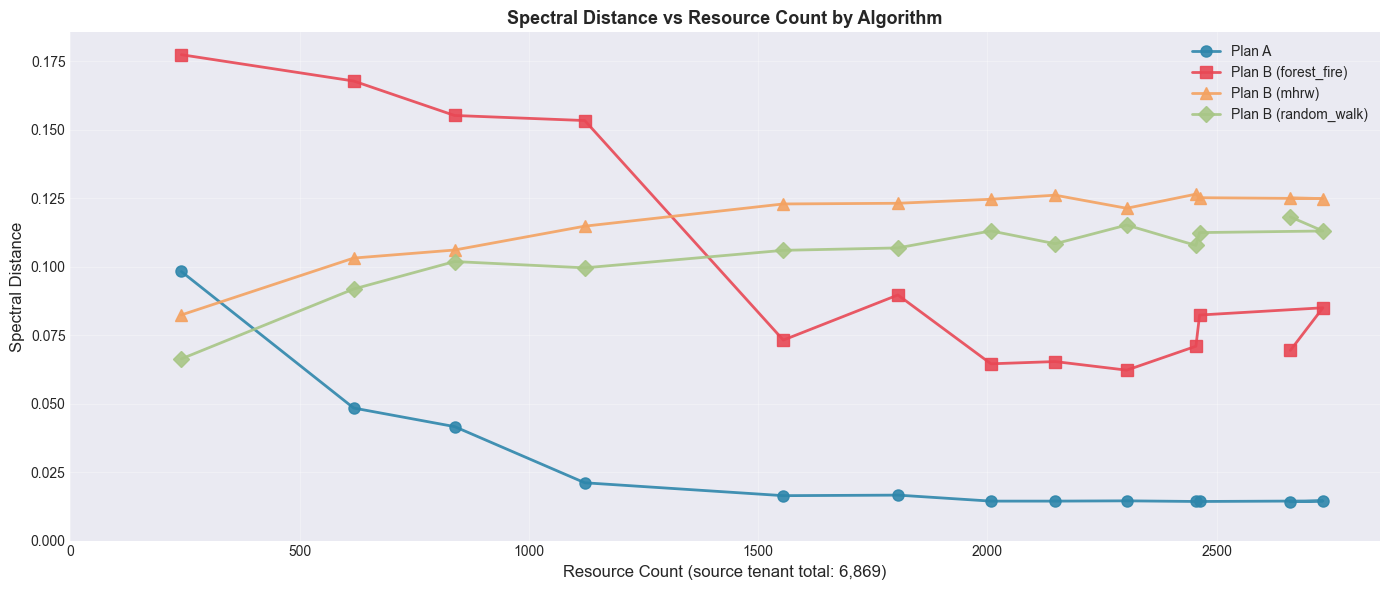

In [14]:
# ── Line plot: spectral distance vs resource count ────────────────────────────
if not sweep_results:
    print('⚠️  No sweep results — run the sweep cell first')
else:
    counts    = sorted(sweep_results.keys())
    resources = [sweep_results[c]['plan_a_resources'] for c in counts]

    colors   = ['#2E86AB', '#E84855', '#F4A261', '#A8C686']
    labels   = ['Plan A'] + [f'Plan B ({a})' for a in SCALE_DOWN_ALGORITHMS]
    all_keys = ['plan_a'] + SCALE_DOWN_ALGORITHMS
    markers  = ['o', 's', '^', 'D']

    fig, ax = plt.subplots(figsize=(14, 6))

    for key, label, color, marker in zip(all_keys, labels, colors, markers):
        dists = [sweep_results[c][key] for c in counts]
        ax.plot(resources, dists, marker=marker, linewidth=2, markersize=8,
                color=color, label=label, alpha=0.9)

    ax.set_xlabel(f'Resource Count (source tenant total: {TOTAL_SOURCE_RESOURCES:,})', fontsize=12)
    ax.set_ylabel('Spectral Distance', fontsize=12)
    ax.set_title('Spectral Distance vs Resource Count by Algorithm',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

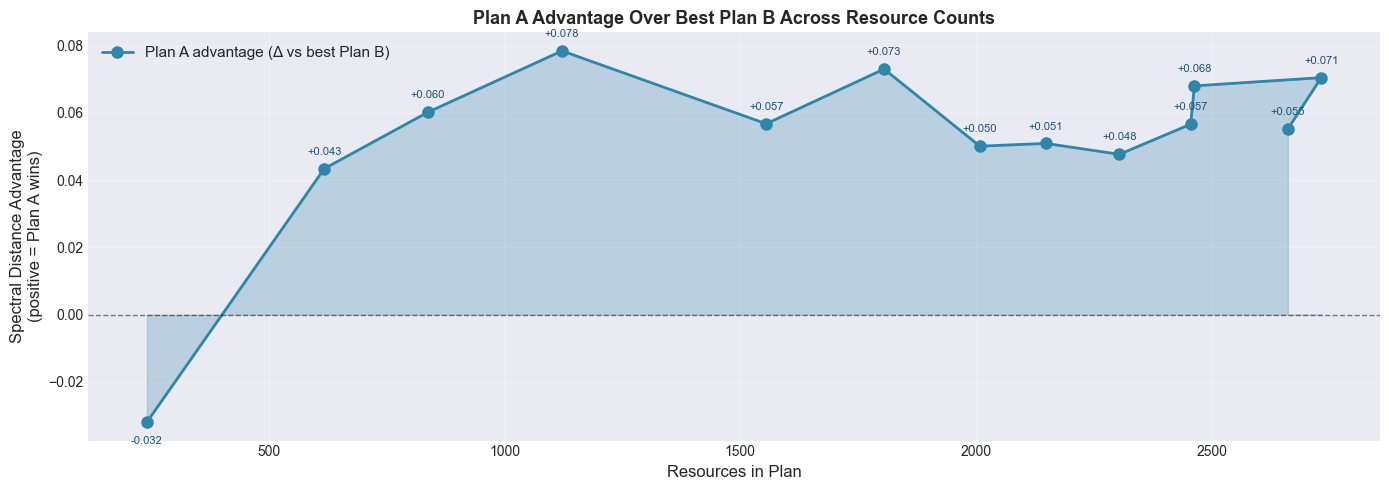


📊 Plan A wins in 12/13 resource levels (average advantage: +0.0523)


In [15]:
# ── Plan A advantage over best Plan B at each resource level ─────────────────
if not sweep_results:
    print('⚠️  No sweep results — run the sweep cell first')
else:
    counts    = sorted(sweep_results.keys())
    resources = [sweep_results[c]['plan_a_resources'] for c in counts]
    plan_a    = [sweep_results[c]['plan_a'] for c in counts]
    best_b    = [min(sweep_results[c][a] for a in SCALE_DOWN_ALGORITHMS) for c in counts]
    gap       = [b - a for a, b in zip(plan_a, best_b)]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.fill_between(resources, 0, gap, alpha=0.25, color='#2E86AB')
    ax.plot(resources, gap, 'o-', linewidth=2, markersize=8, color='#2E86AB',
            label='Plan A advantage (Δ vs best Plan B)')
    ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
    for r, g in zip(resources, gap):
        ax.annotate(f'{g:+.3f}', (r, g),
                    textcoords='offset points', xytext=(0, 10 if g >= 0 else -16),
                    ha='center', fontsize=8, color='#1a5276')

    ax.set_xlabel('Resources in Plan', fontsize=12)
    ax.set_ylabel('Spectral Distance Advantage\n(positive = Plan A wins)', fontsize=12)
    ax.set_title('Plan A Advantage Over Best Plan B Across Resource Counts',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    wins_a = sum(1 for g in gap if g > 0)
    print(f'\n📊 Plan A wins in {wins_a}/{len(counts)} resource levels '
          f'(average advantage: {np.mean(gap):+.4f})')

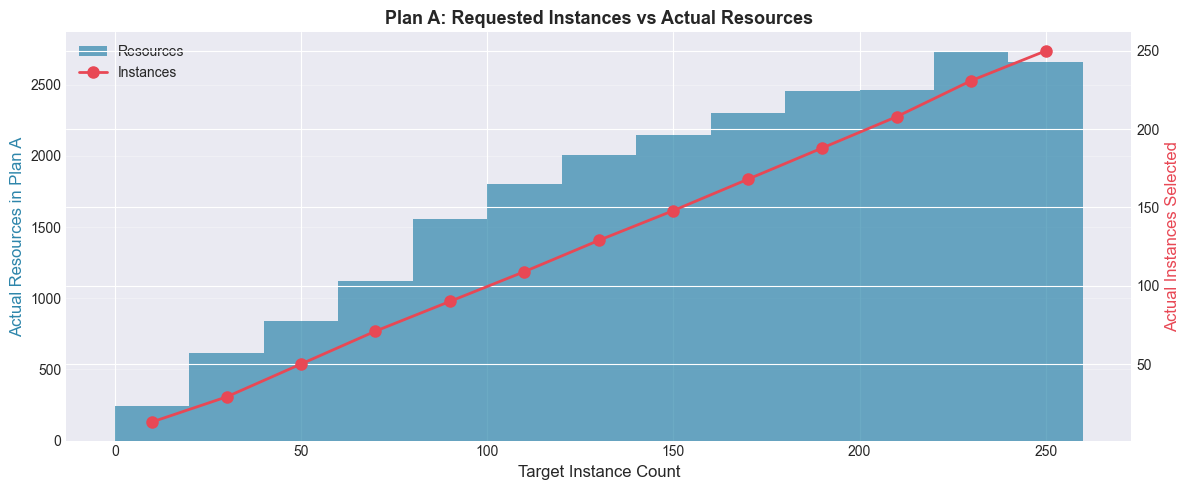


 Requested   Instances   Resources    Res/Inst
─────────────────────────────────────────────
        10          13         242        18.6
        30          29         618        21.3
        50          50         838        16.8
        70          71        1122        15.8
        90          90        1555        17.3
       110         109        1805        16.6
       130         129        2008        15.6
       150         148        2148        14.5
       170         168        2304        13.7
       190         188        2455        13.1
       210         208        2463        11.8
       230         231        2732        11.8
       250         250        2661        10.6


In [16]:
# ── Requested instance count vs actual resources selected (Plan A) ───────────
if not sweep_results:
    print('⚠️  No sweep results — run the sweep cell first')
else:
    counts    = sorted(sweep_results.keys())
    instances = [sweep_results[c]['plan_a_instances'] for c in counts]
    resources = [sweep_results[c]['plan_a_resources'] for c in counts]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax2 = ax.twinx()

    ax.bar(counts, resources, width=20, color='#2E86AB', alpha=0.7, label='Resources')
    ax2.plot(counts, instances, 'o-', color='#E84855', linewidth=2, markersize=8, label='Instances')

    ax.set_xlabel('Target Instance Count', fontsize=12)
    ax.set_ylabel('Actual Resources in Plan A', fontsize=12, color='#2E86AB')
    ax2.set_ylabel('Actual Instances Selected', fontsize=12, color='#E84855')
    ax.set_title('Plan A: Requested Instances vs Actual Resources', fontsize=13, fontweight='bold')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'\n{"Requested":>10}  {"Instances":>10}  {"Resources":>10}  {"Res/Inst":>10}')
    print('─' * 45)
    for c, inst, res in zip(counts, instances, resources):
        ratio = res / inst if inst else 0
        print(f'{c:>10}  {inst:>10}  {res:>10}  {ratio:>10.1f}')

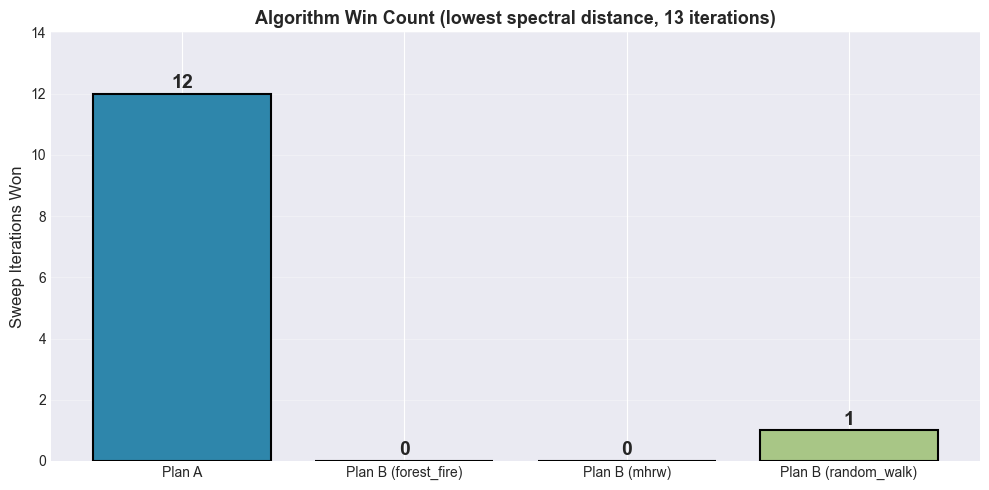


📊 Mean spectral distance per approach:
   Plan A                        : 0.0263
   Plan B (forest_fire)          : 0.1012
   Plan B (mhrw)                 : 0.1174
   Plan B (random_walk)          : 0.1046


In [17]:
# ── Algorithm win-rate summary ───────────────────────────────────────────────
if not sweep_results:
    print('⚠️  No sweep results — run the sweep cell first')
else:
    counts    = sorted(sweep_results.keys())
    all_keys  = ['plan_a'] + SCALE_DOWN_ALGORITHMS
    labels    = ['Plan A'] + [f'Plan B ({a})' for a in SCALE_DOWN_ALGORITHMS]
    colors    = ['#2E86AB', '#E84855', '#F4A261', '#A8C686']

    wins = {k: 0 for k in all_keys}
    for c in counts:
        row      = sweep_results[c]
        best_key = min(all_keys, key=lambda k: row[k])
        wins[best_key] += 1

    fig, ax = plt.subplots(figsize=(10, 5))
    win_vals = [wins[k] for k in all_keys]
    bars = ax.bar(labels, win_vals, color=colors, edgecolor='black', linewidth=1.5)
    for bar, val in zip(bars, win_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                str(val), ha='center', va='bottom', fontsize=14, fontweight='bold')

    ax.set_ylabel('Sweep Iterations Won', fontsize=12)
    ax.set_title(f'Algorithm Win Count (lowest spectral distance, {len(counts)} iterations)',
                 fontsize=13, fontweight='bold')
    ax.set_ylim(0, len(counts) + 1)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print('\n📊 Mean spectral distance per approach:')
    for key, label in zip(all_keys, labels):
        mean_d = np.mean([sweep_results[c][key] for c in counts])
        print(f'   {label:30s}: {mean_d:.4f}')

In [18]:
# (graph topology visualization removed — replaced by sweep comparison above)
print('ℹ️  Graph topology visualization removed — see comparison plot in Section 6.')

ℹ️  Graph topology visualization removed — see comparison plot in Section 6.


---
## 8. Summary & Interpretation

In [19]:
if not sweep_results:
    print('⚠️  Run the sweep cell (Section 6) first.')
else:
    counts   = sorted(sweep_results.keys())
    all_keys = ['plan_a'] + SCALE_DOWN_ALGORITHMS
    labels   = ['Plan A (Architecture)'] + [f'Plan B ({a})' for a in SCALE_DOWN_ALGORITHMS]

    print('=' * 70)
    print('SWEEP SUMMARY: Architecture Replication vs Scale-Down')
    print(f'Instance counts tested: {INSTANCE_COUNTS}')
    print('=' * 70)

    all_plan_a = [sweep_results[c]['plan_a'] for c in counts]
    all_best_b = [min(sweep_results[c][a] for a in SCALE_DOWN_ALGORITHMS) for c in counts]

    print(f'\n📊 Plan A (Architecture Replication):')
    print(f'   Spectral distance range: {min(all_plan_a):.4f} – {max(all_plan_a):.4f}')
    print(f'   Mean spectral distance:  {np.mean(all_plan_a):.4f}')

    print(f'\n📊 Best Plan B (per iteration):')
    print(f'   Spectral distance range: {min(all_best_b):.4f} – {max(all_best_b):.4f}')
    print(f'   Mean spectral distance:  {np.mean(all_best_b):.4f}')

    gap    = np.array(all_best_b) - np.array(all_plan_a)
    wins_a = int((gap > 0).sum())
    print(f'\n🏆 Plan A wins in {wins_a}/{len(counts)} resource levels '
          f'(average advantage: {np.mean(gap):+.4f})')

    print(f'\n📐 Mean spectral distance per approach (all resource levels):')
    for key, label in zip(all_keys, labels):
        mean_d = np.mean([sweep_results[c][key] for c in counts])
        quality = ('EXCELLENT' if mean_d < 0.1
                   else 'GOOD' if mean_d < 0.2
                   else 'MODERATE')
        print(f'   {label:35s}: {mean_d:.4f}  [{quality}]')

    print(f'\n💡 Note: Plan A uses the type-level pattern graph (includes Subscription,')
    print(f'   ResourceGroup, Region, etc.) while Plan B samples :Resource instance nodes')
    print(f'   only — infrastructure types are absent from Plan B projections, which')
    print(f'   structurally increases Plan B spectral distances at all resource levels.')

SWEEP SUMMARY: Architecture Replication vs Scale-Down
Instance counts tested: [10, 30, 50, 70, 90, 110, 130, 150, 170, 190, 210, 230, 250]

📊 Plan A (Architecture Replication):
   Spectral distance range: 0.0141 – 0.0982
   Mean spectral distance:  0.0263

📊 Best Plan B (per iteration):
   Spectral distance range: 0.0622 – 0.1018
   Mean spectral distance:  0.0786

🏆 Plan A wins in 12/13 resource levels (average advantage: +0.0523)

📐 Mean spectral distance per approach (all resource levels):
   Plan A (Architecture)              : 0.0263  [EXCELLENT]
   Plan B (forest_fire)               : 0.1012  [GOOD]
   Plan B (mhrw)                      : 0.1174  [GOOD]
   Plan B (random_walk)               : 0.1046  [GOOD]

💡 Note: Plan A uses the type-level pattern graph (includes Subscription,
   ResourceGroup, Region, etc.) while Plan B samples :Resource instance nodes
   only — infrastructure types are absent from Plan B projections, which
   structurally increases Plan B spectral distances 

---
## 9. Scale-Up Experiment: Higher Instance Counts [250 → 950]
Repeats the same sweep at larger architecture instance counts (250 to 950 in steps of 50)
to see how spectral distance evolves as the replication plan grows toward the full source tenant size.
Followed by a combined view merging both the scale-down and scale-up results.

In [ ]:
import time

SCALE_UP_COUNTS = list(range(15000, 26001, 500))  # [15000, 15500, 16000, ..., 26000]

print(f'🚀 Scale-up sweep: {len(SCALE_UP_COUNTS)} instance counts...')
print(f'   Counts: {SCALE_UP_COUNTS}\n')

scaleup_results = {}

for count in SCALE_UP_COUNTS:
    print(f'{"─"*62}')
    print(f'🔄  instance_count = {count}')

    # ── Plan A ──────────────────────────────────────────────────
    t0 = time.time()
    selected, _, _ = replicator.generate_replication_plan(
        target_instance_count=count,
        use_architecture_distribution=True,
        use_configuration_coherence=True,
        use_spectral_guidance=True,
        spectral_weight=0.4,
        sampling_strategy='coverage',
    )
    plan_a_resources = sum(len(inst) for _, inst in selected)
    target_graph_a   = replicator.target_builder.build_from_instances(selected)
    dist_a           = GraphStructureAnalyzer.compute_spectral_distance(source_pattern_graph, target_graph_a)
    t_a = time.time() - t0
    print(f'  Plan A:  {len(selected):3d} instances  {plan_a_resources:5d} resources  '
          f'spectral={dist_a:.4f}  ({t_a:.1f}s)')

    row = {
        'plan_a_instances': len(selected),
        'plan_a_resources': plan_a_resources,
        'plan_a': dist_a,
    }

    # ── Plan B: sample same resource count ──────────────────────
    target_node_count = min(plan_a_resources, G_full.number_of_nodes())
    for algo in SCALE_DOWN_ALGORITHMS:
        t0            = time.time()
        sampler       = orchestrator.samplers[algo]
        sampled_ids   = await sampler.sample(G_full, target_node_count)
        sampled_graph = G_full.subgraph(sampled_ids).copy()
        type_graph_b  = instance_graph_to_type_graph(sampled_graph, node_properties)
        dist_b        = GraphStructureAnalyzer.compute_spectral_distance(source_pattern_graph, type_graph_b)
        t_b = time.time() - t0
        row[algo] = dist_b
        print(f'  Plan B ({algo:12s}):  {len(sampled_ids):5,} nodes  '
              f'spectral={dist_b:.4f}  ({t_b:.1f}s)')

    scaleup_results[count] = row

print(f'\n{"─"*62}')
print(f'✅ Scale-up sweep complete — {len(scaleup_results)} data points')

🚀 Scale-up sweep: 23 instance counts...
   Counts: [15000, 15500, 16000, 16500, 17000, 17500, 18000, 18500, 19000, 19500, 20000, 20500, 21000, 21500, 22000, 22500, 23000, 23500, 24000, 24500, 25000, 25500, 26000]

──────────────────────────────────────────────────────────────
🔄  instance_count = 15000
  Plan A:  940 instances   5261 resources  spectral=0.0120  (2.9s)
  Plan B (forest_fire ):  5,261 nodes  spectral=0.1210  (0.0s)
  Plan B (mhrw        ):  5,261 nodes  spectral=0.1247  (2.0s)
  Plan B (random_walk ):  5,261 nodes  spectral=0.1220  (1.1s)
──────────────────────────────────────────────────────────────
🔄  instance_count = 15500
  Plan A:  940 instances   5261 resources  spectral=0.0120  (3.7s)
  Plan B (forest_fire ):  5,261 nodes  spectral=0.1206  (0.0s)
  Plan B (mhrw        ):  5,261 nodes  spectral=0.1256  (2.0s)
  Plan B (random_walk ):  5,261 nodes  spectral=0.1218  (1.2s)
──────────────────────────────────────────────────────────────
🔄  instance_count = 16000
  Plan 

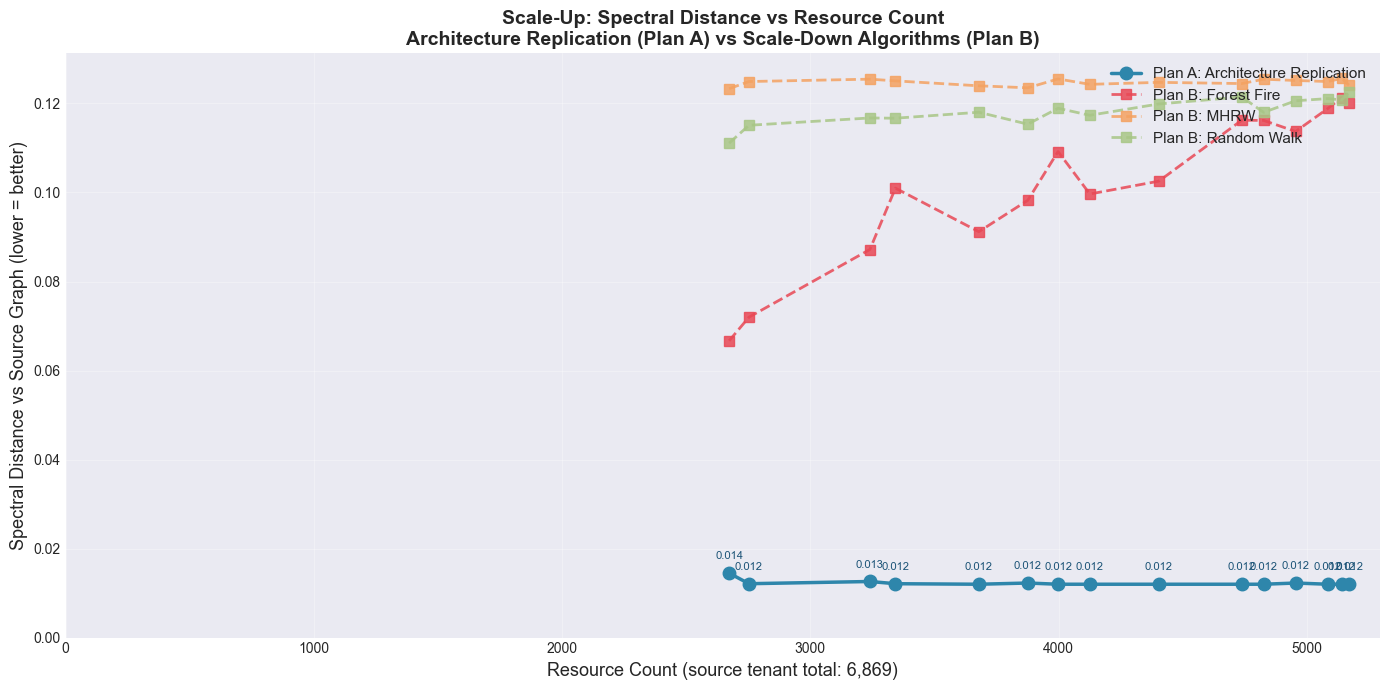


📊 Scale-Up Sweep Results (source tenant: 6,869 resources):
     Covers 2,673 – 5,170 resources (38.9% – 75.3% of source)

Inst Cnt  Resources  % of src         Plan A  forest_fire    mhrw           random_walk  
─────────────────────────────────────────────────────────────────────────────────────────
     250       2673     38.9%         0.0145         0.0667         0.1233         0.1111
     300       2753     40.1%         0.0121         0.0720         0.1249         0.1151
     350       3240     47.2%         0.0126         0.0872         0.1255         0.1167
     400       3343     48.7%         0.0121         0.1010         0.1251         0.1167
     450       3679     53.6%         0.0120         0.0912         0.1240         0.1180
     500       3876     56.4%         0.0123         0.0982         0.1235         0.1153
     550       3998     58.2%         0.0120         0.1092         0.1255         0.1189
     600       4126     60.1%         0.0120         0.0997        

In [ ]:
# ── Scale-up comparison plot ──────────────────────────────────────────────────
counts    = sorted(scaleup_results.keys())
resources = [scaleup_results[c]['plan_a_resources'] for c in counts]
dist_a    = [scaleup_results[c]['plan_a'] for c in counts]

algo_colors = {'forest_fire': '#E84855', 'mhrw': '#F4A261', 'random_walk': '#A8C686'}
algo_labels = {'forest_fire': 'Plan B: Forest Fire', 'mhrw': 'Plan B: MHRW', 'random_walk': 'Plan B: Random Walk'}

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(resources, dist_a, 'o-', linewidth=2.5, markersize=9, color='#2E86AB',
        label='Plan A: Architecture Replication', zorder=5)
for algo in SCALE_DOWN_ALGORITHMS:
    dists = [scaleup_results[c][algo] for c in counts]
    ax.plot(resources, dists, 's--', linewidth=2, markersize=7,
            color=algo_colors[algo], label=algo_labels[algo], alpha=0.85)
for r, d in zip(resources, dist_a):
    ax.annotate(f'{d:.3f}', (r, d), textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=8, color='#1a5276')

ax.set_xlabel(f'Resource Count (source tenant total: {TOTAL_SOURCE_RESOURCES:,})', fontsize=13)
ax.set_ylabel('Spectral Distance vs Source Graph (lower = better)', fontsize=13)
ax.set_title(
    'Scale-Up: Spectral Distance vs Resource Count\n'
    'Architecture Replication (Plan A) vs Scale-Down Algorithms (Plan B)',
    fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

# Summary table
print(f'\n📊 Scale-Up Sweep Results (source tenant: {TOTAL_SOURCE_RESOURCES:,} resources):')
print(f'     Covers {min(resources):,} – {max(resources):,} resources '
      f'({min(resources)/TOTAL_SOURCE_RESOURCES:.1%} – {max(resources)/TOTAL_SOURCE_RESOURCES:.1%} of source)\n')

col_w  = 13
header = (f'{"Inst Cnt":>8}  {"Resources":>9}  {"% of src":>8}  {"Plan A":>{col_w}}  '
          + '  '.join(f'{a:{col_w}}' for a in SCALE_DOWN_ALGORITHMS))
print(header)
print('─' * len(header))
for c in counts:
    row  = scaleup_results[c]
    pct  = row['plan_a_resources'] / TOTAL_SOURCE_RESOURCES
    line = (f'{c:>8}  {row["plan_a_resources"]:>9}  {pct:>8.1%}  {row["plan_a"]:>{col_w}.4f}  '
            + '  '.join(f'{row[a]:>{col_w}.4f}' for a in SCALE_DOWN_ALGORITHMS))
    print(line)

print('\n🏆 Winner per resource count:')
for c in counts:
    row        = scaleup_results[c]
    candidates = {'Plan A': row['plan_a'], **{a: row[a] for a in SCALE_DOWN_ALGORITHMS}}
    winner     = min(candidates, key=candidates.get)
    print(f'   {c:3d} instances ({row["plan_a_resources"]:5d} resources, '
          f'{row["plan_a_resources"]/TOTAL_SOURCE_RESOURCES:.1%} of source): '
          f'{winner}  (dist={candidates[winner]:.4f})')

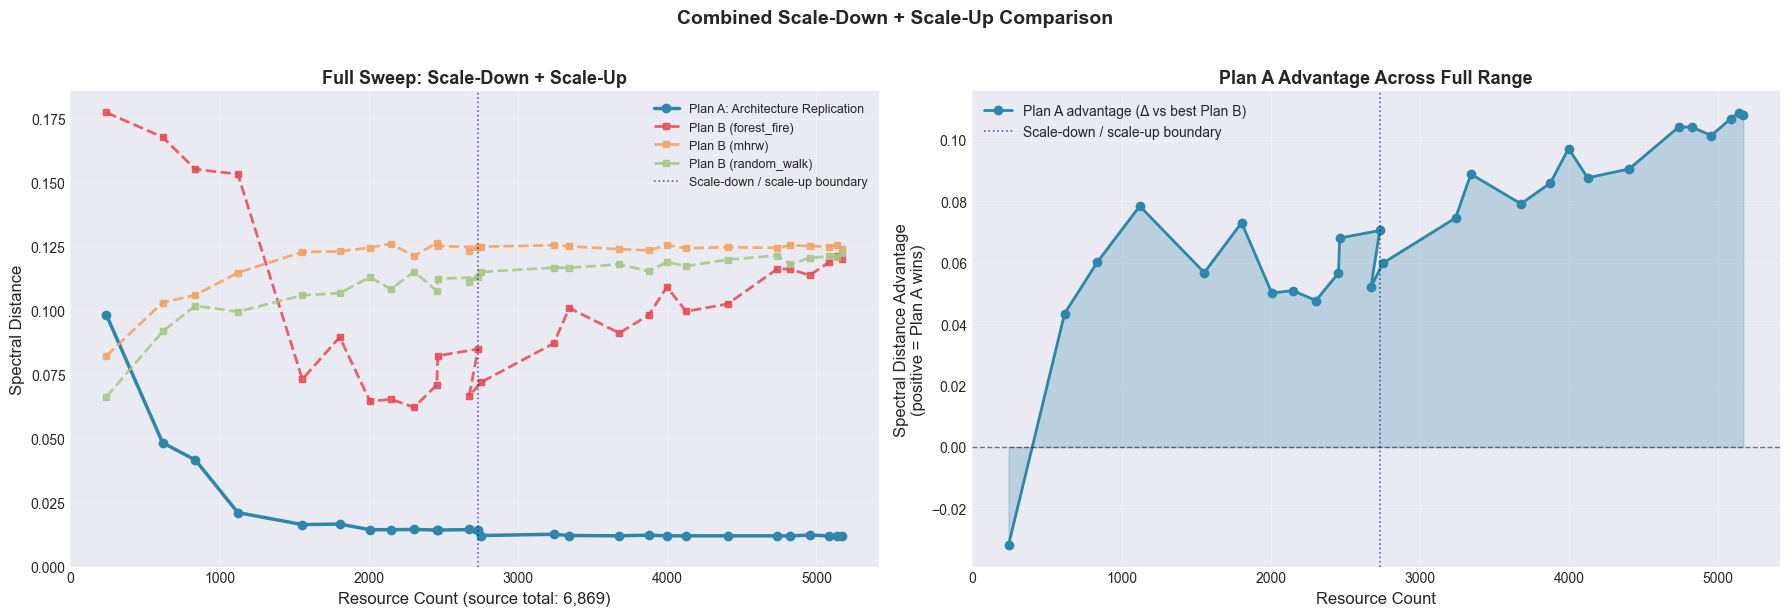


📊 Combined results across 27 resource levels:
   Plan A wins: 26/27 (96%)
   Average advantage: +0.0731


In [ ]:
# ── Combined view: scale-down + scale-up ─────────────────────────────────────
all_results = {**sweep_results, **scaleup_results}
counts_all  = sorted(all_results.keys())
res_all     = [all_results[c]['plan_a_resources'] for c in counts_all]
da_all      = [all_results[c]['plan_a'] for c in counts_all]

algo_colors = {'forest_fire': '#E84855', 'mhrw': '#F4A261', 'random_walk': '#A8C686'}
boundary_x  = max(sweep_results[c]['plan_a_resources'] for c in sweep_results)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: full combined line plot
ax = axes[0]
ax.plot(res_all, da_all, 'o-', linewidth=2.5, markersize=6, color='#2E86AB',
        label='Plan A: Architecture Replication')
for algo in SCALE_DOWN_ALGORITHMS:
    dists = [all_results[c][algo] for c in counts_all]
    ax.plot(res_all, dists, 's--', linewidth=2, markersize=5,
            color=algo_colors[algo], label=f'Plan B ({algo})', alpha=0.85)
ax.axvline(x=boundary_x, color='navy', linewidth=1.2, linestyle=':',
           alpha=0.6, label='Scale-down / scale-up boundary')
ax.set_xlabel(f'Resource Count (source total: {TOTAL_SOURCE_RESOURCES:,})', fontsize=12)
ax.set_ylabel('Spectral Distance', fontsize=12)
ax.set_title('Full Sweep: Scale-Down + Scale-Up', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

# Right: Plan A advantage over best Plan B across full range
ax = axes[1]
best_b_all = [min(all_results[c][a] for a in SCALE_DOWN_ALGORITHMS) for c in counts_all]
gap_all    = [b - a for a, b in zip(da_all, best_b_all)]
ax.fill_between(res_all, 0, gap_all, alpha=0.25, color='#2E86AB')
ax.plot(res_all, gap_all, 'o-', linewidth=2, markersize=6, color='#2E86AB',
        label='Plan A advantage (Δ vs best Plan B)')
ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.axvline(x=boundary_x, color='navy', linewidth=1.2, linestyle=':', alpha=0.6,
           label='Scale-down / scale-up boundary')
ax.set_xlabel('Resource Count', fontsize=12)
ax.set_ylabel('Spectral Distance Advantage\n(positive = Plan A wins)', fontsize=12)
ax.set_title('Plan A Advantage Across Full Range', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('Combined Scale-Down + Scale-Up Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

wins_all = sum(1 for g in gap_all if g > 0)
print(f'\n📊 Combined results across {len(counts_all)} resource levels:')
print(f'   Plan A wins: {wins_all}/{len(counts_all)} ({wins_all/len(counts_all):.0%})')
print(f'   Average advantage: {np.mean(gap_all):+.4f}')

---
## 10. Resource-Level Fidelity: Random Walk vs Architecture Replication

Compares actual deployed resource fidelity (location + tag exact match) across replication strategies.
Architecture replication runs 154009 (12 instances) and 171613 (31 instances) are combined into a single dataset — deduplicating by resource name, with the later run taking precedence.

`exact_match` = same location and tags · `drifted` = property mismatch · `missing_source/target` = no counterpart found

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

output_dir = Path.cwd().parent / 'output'

# ── Load and combine arch replication runs ────────────────────────────────────
rw_df      = pd.read_csv(output_dir / 'random_walk_fidelity_023757.csv')
arch_154   = pd.read_csv(output_dir / 'arch_replication_fidelity_154009.csv')
arch_171   = pd.read_csv(output_dir / 'arch_replication_fidelity_171613.csv')

for df in [rw_df, arch_154, arch_171]:
    df['status'] = df['status'].str.strip().str.lower()

# Combine: 171613 takes precedence on duplicate resource_name
arch_combined = (
    pd.concat([arch_154, arch_171])
    .drop_duplicates(subset=['resource_name'], keep='last')
    .reset_index(drop=True)
)

STATUS_ORDER  = ['exact_match', 'drifted', 'missing_source', 'missing_target']
STATUS_LABELS = {'exact_match': 'Exact Match', 'drifted': 'Drifted',
                 'missing_source': 'Missing (no source)', 'missing_target': 'Missing (not deployed)'}
STATUS_COLORS = {'exact_match': '#2E86AB', 'drifted': '#F4A261',
                 'missing_source': '#E84855', 'missing_target': '#A8C686'}

def summarise(df, label, color):
    counts = {s: int((df['status'] == s).sum()) for s in STATUS_ORDER}
    total  = len(df)
    score  = counts['exact_match'] / total * 100 if total else 0
    return {'label': label, 'color': color, 'counts': counts, 'total': total, 'score': score}

runs = [
    summarise(rw_df,        'Random Walk\n(run 023757)',               '#E84855'),
    summarise(arch_combined, 'Architecture Replication\n(combined)',   '#2E86AB'),
]

print(f'{"Run":40s}  {"Total":>6}  {"Fidelity":>9}  Breakdown')
print('─' * 80)
for r in runs:
    print(f"{r['label'].replace(chr(10),' '):40s}  {r['total']:>6}  {r['score']:>8.1f}%  {r['counts']}")

# ── Figure: 2-panel ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
x       = np.arange(len(runs))
n       = len(STATUS_ORDER)
width   = 0.18
offsets = np.linspace(-(n-1)/2*width, (n-1)/2*width, n)

# Left: absolute status counts
ax = axes[0]
for i, status in enumerate(STATUS_ORDER):
    vals = [r['counts'][status] for r in runs]
    bars = ax.bar(x + offsets[i], vals, width,
                  label=STATUS_LABELS[status], color=STATUS_COLORS[status],
                  edgecolor='black', linewidth=0.8)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([r['label'] for r in runs], fontsize=11)
ax.set_ylabel('Resource Count', fontsize=12)
ax.set_title('Fidelity Status: Absolute Counts', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(bottom=0)

# Right: overall fidelity score
ax2 = axes[1]
bars = ax2.bar([r['label'] for r in runs], [r['score'] for r in runs],
               color=[r['color'] for r in runs], edgecolor='black', linewidth=1.5, width=0.45)
for bar, r in zip(bars, runs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f"{r['score']:.1f}%\n({r['counts']['exact_match']}/{r['total']})",
             ha='center', va='bottom', fontsize=12, fontweight='bold')

ax2.axhline(100, color='green', linestyle='--', linewidth=1.5, alpha=0.5, label='100% target')
ax2.set_ylabel('Fidelity Score (%)', fontsize=12)
ax2.set_title('Overall Fidelity Score\n(exact location + tag match)', fontsize=13, fontweight='bold')
ax2.set_ylim(0, 120)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Resource Fidelity Comparison: Replication Strategies',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


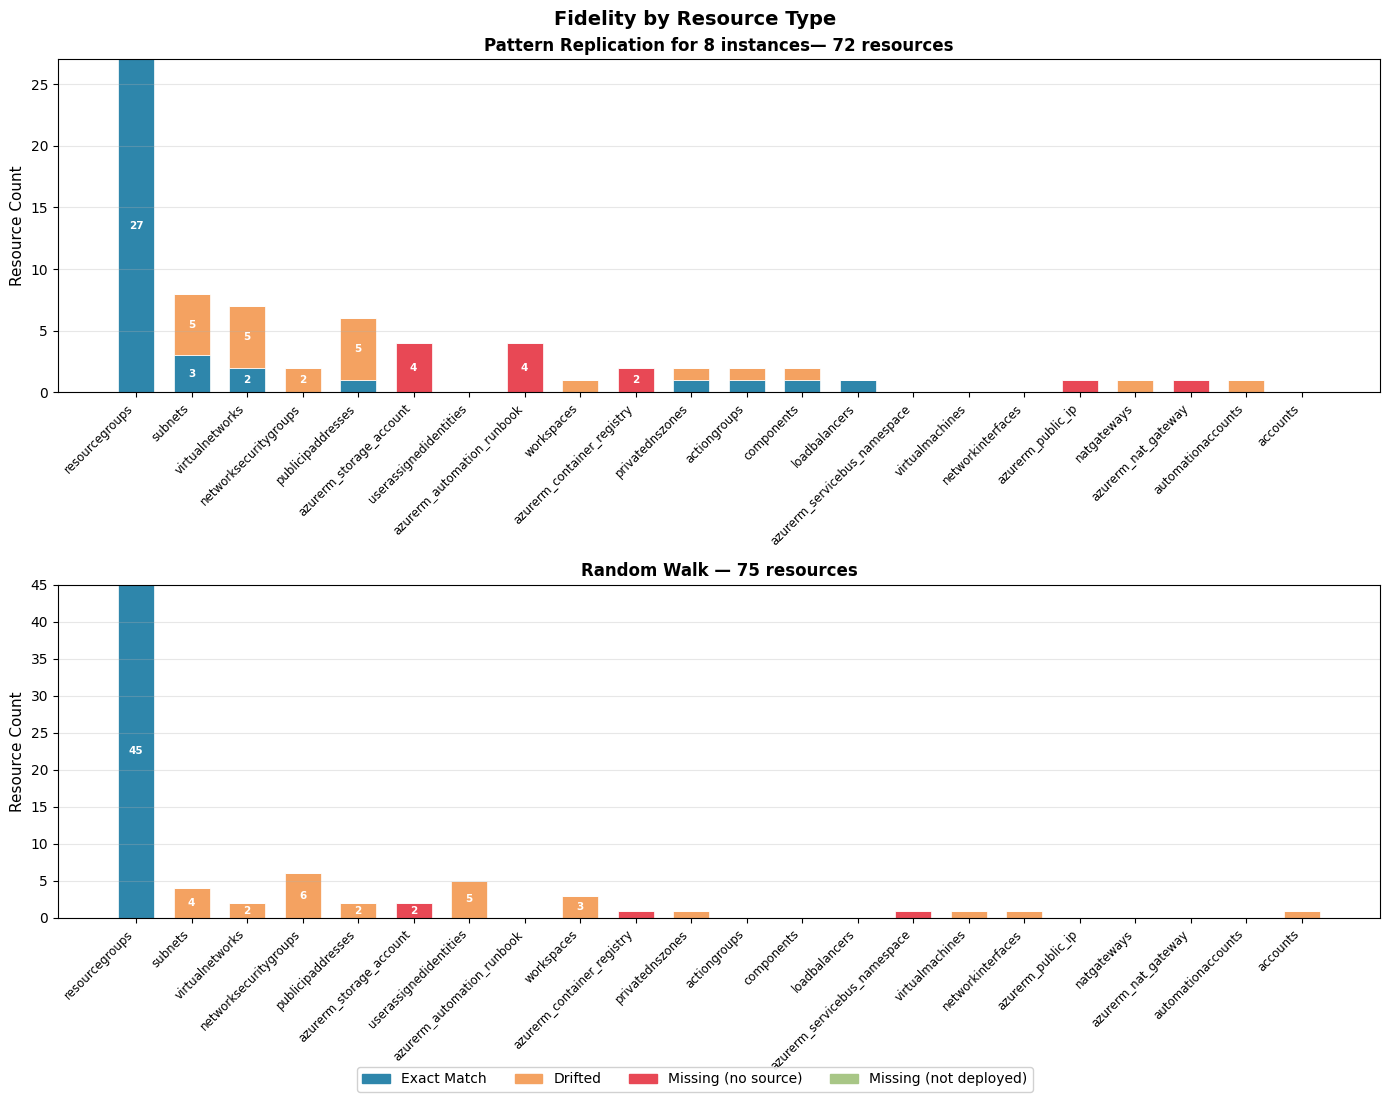

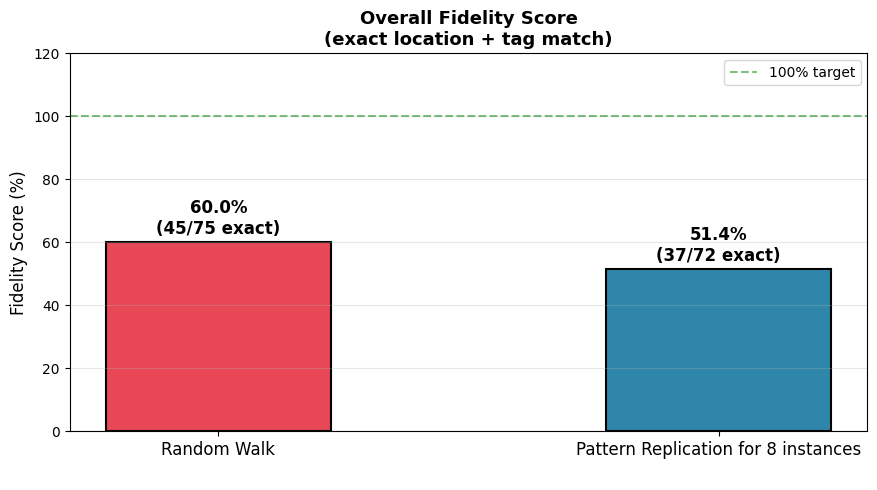

In [6]:

# ── Resource Type Fidelity Breakdown ─────────────────────────────────────────
import matplotlib.patches as mpatches

# Note: 154009 CSV uses resource_name/resource_type columns; normalise to name/type
_arch_154 = pd.read_csv(output_dir / 'arch_replication_fidelity_154009.csv')
_arch_154  = _arch_154.rename(columns={'resource_name': 'name', 'resource_type': 'type'})
_arch_171  = pd.read_csv(output_dir / 'arch_replication_fidelity_171613.csv')
_rw_df     = pd.read_csv(output_dir / 'random_walk_fidelity_023757.csv')

for _df in [_arch_154, _arch_171, _rw_df]:
    _df['status']     = _df['status'].str.strip().str.lower()
    _df['short_type'] = _df['type'].str.split('/').str[-1].str.lower()

_arch_combined = (
    pd.concat([_arch_154, _arch_171])
    .drop_duplicates(subset=['name'], keep='last')
    .reset_index(drop=True)
)

_STATUS_ORDER  = ['exact_match', 'drifted', 'missing_source', 'missing_target']
_STATUS_LABELS = {'exact_match': 'Exact Match', 'drifted': 'Drifted',
                  'missing_source': 'Missing (no source)', 'missing_target': 'Missing (not deployed)'}
_STATUS_COLORS = {'exact_match': '#2E86AB', 'drifted': '#F4A261',
                  'missing_source': '#E84855', 'missing_target': '#A8C686'}

def _type_pivot(df):
    pivot = (df.groupby(['short_type', 'status'])
               .size()
               .unstack(fill_value=0)
               .reindex(columns=_STATUS_ORDER, fill_value=0))
    pivot['total'] = pivot.sum(axis=1)
    return pivot

pivot_arch = _type_pivot(_arch_combined)
pivot_rw   = _type_pivot(_rw_df)

# Shared x-axis: union of all types, sorted by combined total descending (left = most)
all_types = sorted(
    set(pivot_arch.index) | set(pivot_rw.index),
    key=lambda t: (
        (pivot_arch.loc[t, 'total'] if t in pivot_arch.index else 0)
      + (pivot_rw.loc[t,   'total'] if t in pivot_rw.index   else 0)
    ),
    reverse=True
)
pivot_arch = pivot_arch.reindex(all_types, fill_value=0)
pivot_rw   = pivot_rw.reindex(all_types, fill_value=0)

def _plot_type_breakdown_v(ax, pivot, title):
    """Vertical stacked bar chart — resource types on x-axis."""
    x     = np.arange(len(all_types))
    bottoms = np.zeros(len(all_types))
    for status in _STATUS_ORDER:
        vals = pivot.get(status, pd.Series(0, index=pivot.index)).values.astype(float)
        ax.bar(x, vals, bottom=bottoms, color=_STATUS_COLORS[status],
               edgecolor='white', linewidth=0.5, width=0.65)
        for j, (v, b) in enumerate(zip(vals, bottoms)):
            if v >= 2:
                ax.text(x[j], b + v / 2, str(int(v)),
                        ha='center', va='center', fontsize=7.5,
                        color='white', fontweight='bold')
        bottoms += vals
    ax.set_xticks(x)
    ax.set_xticklabels(all_types, rotation=45, ha='right', fontsize=8.5)
    ax.set_ylabel('Resource Count', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(bottom=0)

# ── Figure 1: Type breakdown (2 rows × 1 col) ───────────────────────────────
fig1, axes1 = plt.subplots(2, 1, figsize=(14, 11), sharex=False)

_plot_type_breakdown_v(axes1[0], pivot_arch,
    f'Pattern Replication for 8 instances— {len(_arch_combined)} resources')
_plot_type_breakdown_v(axes1[1], pivot_rw,
    f'Random Walk — {len(_rw_df)} resources')

handles = [mpatches.Patch(color=_STATUS_COLORS[s], label=_STATUS_LABELS[s])
           for s in _STATUS_ORDER]
fig1.legend(handles=handles, loc='lower center', ncol=4, fontsize=10,
            bbox_to_anchor=(0.5, -0.01), framealpha=0.9)

plt.suptitle('Fidelity by Resource Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Figure 2: Overall fidelity score ────────────────────────────────────────
_runs = [
    ('Random Walk\n',            _rw_df,        '#E84855'),
    ('Pattern Replication for 8 instances\n', _arch_combined, '#2E86AB'),
]

fig2, ax2 = plt.subplots(figsize=(9, 5))
x2 = np.arange(len(_runs))

for i, (label, df, color) in enumerate(_runs):
    counts   = {s: int((df['status'] == s).sum()) for s in _STATUS_ORDER}
    total    = len(df)
    fidelity = counts['exact_match'] / total * 100 if total else 0
    bar = ax2.bar(i, fidelity, color=color, edgecolor='black', linewidth=1.5, width=0.45)
    ax2.text(i, fidelity + 1.5,
             f"{fidelity:.1f}%\n({counts['exact_match']}/{total} exact)",
             ha='center', va='bottom', fontsize=12, fontweight='bold')

ax2.axhline(100, color='green', linestyle='--', linewidth=1.5, alpha=0.5, label='100% target')
ax2.set_xticks(x2)
ax2.set_xticklabels([r[0] for r in _runs], fontsize=12)
ax2.set_ylabel('Fidelity Score (%)', fontsize=12)
ax2.set_title('Overall Fidelity Score\n(exact location + tag match)',
              fontsize=13, fontweight='bold')
ax2.set_ylim(0, 120)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
